# 02b. Data Preprocessing & Feature Engineering — **with PCA**

**Objective:** Same pipeline as `02_preprocessing.ipynb` but adds a **PCA dimensionality reduction** step after the ColumnTransformer and before SMOTE. The reduced representations are saved to `03_processed_pca/` so all four downstream models can use them.

**Additions over 02:**
- `sklearn.decomposition.PCA` fitted on `X_train_proc` (already scaled/encoded), never on val/test.
- Variance threshold: **95%** of explained variance retained (configurable via `PCA_VARIANCE_THRESHOLD`).
- Diagnostic plots: scree plot, cumulative variance curve, 2D PC scatter (pre/post-SMOTE), top feature loadings.
- SMOTE applied to the PCA space.
- Saves `preprocessor.pkl` + `pca.pkl` so downstream notebooks need no re-fitting.

**Pipeline outputs (saved to `03_processed_pca/`):**
- `X_train.csv`, `X_val.csv`, `X_test.csv` — PCA-reduced (PC1…PCk columns)
- `X_train_smote.csv` — PCA-reduced + SMOTE-resampled
- `y_train.csv`, `y_val.csv`, `y_test.csv`, `y_train_smote.csv`
- `preprocessor.pkl`, `pca.pkl`, `feature_names.csv` (PC1…PCk)

**Model-specific notes:**
| Step | Logistic Regression | Elastic Net | Random Forest | MLP |
|---|---|---|---|---|
| PCA | Beneficial — reduces collinear features | Same as LR | Less critical but compatible | Beneficial — reduces input width |
| StandardScaler | Already done pre-PCA | Same | Harmless | Already done pre-PCA |

## 0. Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler, OrdinalEncoder, OneHotEncoder, FunctionTransformer
)
from sklearn.impute import SimpleImputer
from sklearn.decomposition import PCA          # ← NEW
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

SEED = 42
np.random.seed(SEED)

# Variance threshold for PCA component selection
PCA_VARIANCE_THRESHOLD = 0.95  # retain components that explain 95% of variance

# mount drive
from google.colab import drive
drive.mount('/content/drive')

DATA_DIR = "/content/drive/MyDrive/MLDL/loan-default-project/01_data/01_raw"
OUT_DIR  = "/content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca"
os.makedirs(OUT_DIR, exist_ok=True)

print("Setup complete.")
print(f"PCA variance threshold: {PCA_VARIANCE_THRESHOLD*100:.0f}%")

Mounted at /content/drive
Setup complete.
PCA variance threshold: 95%


## 1. Load raw data

In [2]:
df = pd.read_csv(f"{DATA_DIR}/application_train.csv")
print(f"Raw shape: {df.shape}")
print(f"Target distribution:\n{df['TARGET'].value_counts(normalize=True).round(4)}")

Raw shape: (307511, 122)
Target distribution:
TARGET
0    0.9193
1    0.0807
Name: proportion, dtype: float64


## 2. Row-level cleaning

Drop 6 rows with `XNA` / `Unknown` in small-cardinality categoricals (confirmed in EDA section 5).
These are not imputable — they are genuinely ambiguous entries.

In [3]:
before = len(df)

# CODE_GENDER has 4 XNA rows; NAME_FAMILY_STATUS has 2 Unknown rows
df = df[df['CODE_GENDER'] != 'XNA']
df = df[df['NAME_FAMILY_STATUS'] != 'Unknown']

df = df.reset_index(drop=True)
print(f"Dropped {before - len(df)} ambiguous rows. New shape: {df.shape}")

Dropped 6 ambiguous rows. New shape: (307505, 122)


## 3. Feature Engineering (pre-split)

Engineer features that use the raw columns **before** we drop those columns or split the data.
All engineered features are domain-motivated ratios from the EDA (section 6.4 pairplots confirmed
the structural relationships these ratios capture).

In [4]:
# --- 3.1 DAYS_EMPLOYED sentinel fix ---
df['DAYS_EMPLOYED_ANOM'] = (df['DAYS_EMPLOYED'] == 365243).astype(int)
df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].replace(365243, np.nan)
print(f"DAYS_EMPLOYED_ANOM flag: {df['DAYS_EMPLOYED_ANOM'].sum():,} unemployed applicants flagged")

# --- 3.2 Age in years (from DAYS_BIRTH) ---
df['age_years'] = -df['DAYS_BIRTH'] / 365.25

# --- 3.3 Flip sign on remaining DAYS_* columns ---
for col in ['DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE']:
    df[col] = -df[col]

df['DAYS_EMPLOYED'] = df['DAYS_EMPLOYED'].apply(lambda x: -x if pd.notna(x) and x < 0 else x)

# --- 3.4 Engineered ratio features ---
df['CREDIT_INCOME_RATIO']  = df['AMT_CREDIT']  / df['AMT_INCOME_TOTAL']
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / df['AMT_INCOME_TOTAL']
df['CREDIT_TERM']          = df['AMT_CREDIT']  / df['AMT_ANNUITY']
df['CREDIT_GOODS_RATIO']   = df['AMT_CREDIT']  / df['AMT_GOODS_PRICE']

for col in ['CREDIT_INCOME_RATIO', 'ANNUITY_INCOME_RATIO', 'CREDIT_TERM', 'CREDIT_GOODS_RATIO']:
    df[col] = df[col].replace([np.inf, -np.inf], np.nan)

print("\nEngineered features created:")
print("  DAYS_EMPLOYED_ANOM, age_years")
print("  CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, CREDIT_GOODS_RATIO")
print(f"\nDataset shape after feature engineering: {df.shape}")

DAYS_EMPLOYED_ANOM flag: 55,374 unemployed applicants flagged

Engineered features created:
  DAYS_EMPLOYED_ANOM, age_years
  CREDIT_INCOME_RATIO, ANNUITY_INCOME_RATIO, CREDIT_TERM, CREDIT_GOODS_RATIO

Dataset shape after feature engineering: (307505, 128)


## 4. Drop columns

49 columns identified in EDA section 10 (preprocessing to-do) are dropped:
- `SK_ID_CURR`: identifier, not a feature
- `DAYS_BIRTH`: replaced by `age_years`
- Zero-variance flags (`FLAG_MOBIL`, `FLAG_CONT_MOBILE`)
- Near-duplicate (`REGION_RATING_CLIENT_W_CITY` = 0.95 corr with `REGION_RATING_CLIENT`)
- `OWN_CAR_AGE`: 66% missing, redundant with `FLAG_OWN_CAR`
- Entire G1 building-features block (~50% missing, ~0 correlation with TARGET)
- Rare `FLAG_DOCUMENT_*` columns with < 1% positive rate

In [5]:
COLS_TO_DROP = [
    'SK_ID_CURR',
    'DAYS_BIRTH',
    'FLAG_MOBIL', 'FLAG_CONT_MOBILE',
    'REGION_RATING_CLIENT_W_CITY',
    'OWN_CAR_AGE',
    'APARTMENTS_AVG','APARTMENTS_MEDI','APARTMENTS_MODE',
    'BASEMENTAREA_AVG','BASEMENTAREA_MEDI','BASEMENTAREA_MODE',
    'YEARS_BEGINEXPLUATATION_AVG','YEARS_BEGINEXPLUATATION_MEDI','YEARS_BEGINEXPLUATATION_MODE',
    'YEARS_BUILD_AVG','YEARS_BUILD_MEDI','YEARS_BUILD_MODE',
    'COMMONAREA_AVG','COMMONAREA_MEDI','COMMONAREA_MODE',
    'ELEVATORS_AVG','ELEVATORS_MEDI','ELEVATORS_MODE',
    'ENTRANCES_AVG','ENTRANCES_MEDI','ENTRANCES_MODE',
    'FLOORSMAX_AVG','FLOORSMAX_MEDI','FLOORSMAX_MODE',
    'FLOORSMIN_AVG','FLOORSMIN_MEDI','FLOORSMIN_MODE',
    'LANDAREA_AVG','LANDAREA_MEDI','LANDAREA_MODE',
    'LIVINGAPARTMENTS_AVG','LIVINGAPARTMENTS_MEDI','LIVINGAPARTMENTS_MODE',
    'LIVINGAREA_AVG','LIVINGAREA_MEDI','LIVINGAREA_MODE',
    'NONLIVINGAPARTMENTS_AVG','NONLIVINGAPARTMENTS_MEDI','NONLIVINGAPARTMENTS_MODE',
    'NONLIVINGAREA_AVG','NONLIVINGAREA_MEDI','NONLIVINGAREA_MODE',
    'FONDKAPREMONT_MODE','HOUSETYPE_MODE','TOTALAREA_MODE','WALLSMATERIAL_MODE','EMERGENCYSTATE_MODE',
    'FLAG_DOCUMENT_2','FLAG_DOCUMENT_4','FLAG_DOCUMENT_7','FLAG_DOCUMENT_9','FLAG_DOCUMENT_10',
    'FLAG_DOCUMENT_12','FLAG_DOCUMENT_13','FLAG_DOCUMENT_14','FLAG_DOCUMENT_15',
    'FLAG_DOCUMENT_17','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21',
]

existing_drops = [c for c in COLS_TO_DROP if c in df.columns]
df.drop(columns=existing_drops, inplace=True)

print(f"Dropped {len(existing_drops)} columns.")
print(f"Dataset shape after drops: {df.shape}")

Dropped 66 columns.
Dataset shape after drops: (307505, 62)


## 5. Hard-cap single-point outliers

These columns are mostly well-behaved counts with one or two extreme values that are almost
certainly data-entry errors. We cap at a hard threshold rather than a percentile because
99% of values are already clean. See EDA section 8.1 for the IQR evidence.

In [6]:
HARD_CAPS = {
    'CNT_CHILDREN':              10,
    'CNT_FAM_MEMBERS':           10,
    'OBS_30_CNT_SOCIAL_CIRCLE':  30,
    'OBS_60_CNT_SOCIAL_CIRCLE':  30,
    'AMT_REQ_CREDIT_BUREAU_QRT': 20,
}

for col, cap in HARD_CAPS.items():
    if col in df.columns:
        n_capped = (df[col] > cap).sum()
        df[col] = df[col].clip(upper=cap)
        print(f"  {col}: capped {n_capped} values at {cap}")

  CNT_CHILDREN: capped 8 values at 10
  CNT_FAM_MEMBERS: capped 11 values at 10
  OBS_30_CNT_SOCIAL_CIRCLE: capped 2 values at 30
  OBS_60_CNT_SOCIAL_CIRCLE: capped 2 values at 30
  AMT_REQ_CREDIT_BUREAU_QRT: capped 1 values at 20


## 6. Train / Validation / Test split

**Critical:** We split BEFORE fitting any imputer/scaler/PCA to prevent data leakage.
All transformers are fitted on X_train only and applied to val/test.

Split: 70% train / 15% val / 15% test, stratified on TARGET.

In [7]:
X = df.drop(columns=['TARGET'])
y = df['TARGET']

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=SEED
)

print(f"Train:  {X_train.shape}  | default rate: {y_train.mean():.4f}")
print(f"Val:    {X_val.shape}   | default rate: {y_val.mean():.4f}")
print(f"Test:   {X_test.shape}  | default rate: {y_test.mean():.4f}")

Train:  (215253, 61)  | default rate: 0.0807
Val:    (46126, 61)   | default rate: 0.0807
Test:   (46126, 61)  | default rate: 0.0807


## 7. Define column groups for the pipeline

We route columns to different transformers in the ColumnTransformer based on their type
and the preprocessing decision documented in EDA section 10.

In [8]:
# --- 7.1 Ordinal encode: education (natural order confirmed in EDA section 6.1) ---
EDUCATION_ORDER = [
    ['Lower secondary', 'Secondary / secondary special',
     'Incomplete higher', 'Higher education', 'Academic degree']
]
ordinal_cols = ['NAME_EDUCATION_TYPE']

# --- 7.2 One-hot encode: standard low-cardinality categoricals ---
onehot_cols = [
    'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
    'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE',
    'OCCUPATION_TYPE',
]
onehot_cols = [c for c in onehot_cols if c in X_train.columns]

# --- 7.3 Monetary columns: log1p transform then scale ---
monetary_cols = ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
monetary_cols = [c for c in monetary_cols if c in X_train.columns]

# --- 7.4 EXT_SOURCE columns: impute + add missingness flag + scale ---
ext_source_cols = ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_source_cols = [c for c in ext_source_cols if c in X_train.columns]

# Add missingness flags to train/val/test NOW (before pipeline)
for split_X in [X_train, X_val, X_test]:
    for col in ext_source_cols:
        split_X[f'{col}_MISSING'] = split_X[col].isna().astype(int)

ext_missing_flags = [f'{c}_MISSING' for c in ext_source_cols]

# --- 7.5 All remaining numeric columns: impute median + scale ---
all_cat = set(ordinal_cols + onehot_cols)
all_special_numeric = set(
    monetary_cols + ext_source_cols + ext_missing_flags
    + ['DAYS_EMPLOYED_ANOM']
)

numeric_rest = [
    c for c in X_train.columns
    if c not in all_cat and c not in all_special_numeric
    and X_train[c].dtype in [np.float64, np.int64, np.float32, np.int32, 'float64', 'int64']
]

print(f"ordinal_cols:       {ordinal_cols}")
print(f"onehot_cols ({len(onehot_cols)}):   {onehot_cols}")
print(f"monetary_cols:      {monetary_cols}")
print(f"ext_source_cols:    {ext_source_cols}")
print(f"ext_missing_flags:  {ext_missing_flags}")
print(f"numeric_rest ({len(numeric_rest)}):  {numeric_rest[:10]} ...")

ordinal_cols:       ['NAME_EDUCATION_TYPE']
onehot_cols (11):   ['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'OCCUPATION_TYPE']
monetary_cols:      ['AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE']
ext_source_cols:    ['EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3']
ext_missing_flags:  ['EXT_SOURCE_1_MISSING', 'EXT_SOURCE_2_MISSING', 'EXT_SOURCE_3_MISSING']
numeric_rest (41):  ['CNT_CHILDREN', 'REGION_POPULATION_RELATIVE', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_PHONE', 'FLAG_EMAIL', 'CNT_FAM_MEMBERS'] ...


## 8. Impute semantic categoricals before the pipeline

`OCCUPATION_TYPE` (31% missing) and `NAME_TYPE_SUITE` (0.4% missing): missingness is
semantically meaningful. Fill with literal string `'Missing'` rather than collapsing to mode.

In [9]:
SEMANTIC_NAN_COLS = ['OCCUPATION_TYPE', 'NAME_TYPE_SUITE']

for col in SEMANTIC_NAN_COLS:
    for split_X in [X_train, X_val, X_test]:
        if col in split_X.columns:
            split_X[col] = split_X[col].fillna('Missing')

print("Semantic NaN columns filled with 'Missing'.")

Semantic NaN columns filled with 'Missing'.


## 9. Rare-category grouping for high-cardinality categoricals

Categories that appear in <1% of the TRAINING set get collapsed to `'Other'`.
Threshold fitted on training set only; same mapping applied to val/test.

In [10]:
RARE_THRESHOLD = 0.01
HIGH_CARD_COLS = ['ORGANIZATION_TYPE', 'NAME_INCOME_TYPE', 'OCCUPATION_TYPE']

PROTECTED_CATS = {
    'NAME_INCOME_TYPE': ['Maternity leave', 'Unemployed'],
}

rare_map = {}

for col in HIGH_CARD_COLS:
    if col not in X_train.columns:
        continue
    freq = X_train[col].value_counts(normalize=True)
    protected = PROTECTED_CATS.get(col, [])
    rare_cats = freq[(freq < RARE_THRESHOLD) & (~freq.index.isin(protected))].index.tolist()
    rare_map[col] = rare_cats

    for split_X in [X_train, X_val, X_test]:
        split_X[col] = split_X[col].apply(
            lambda v: 'Other' if v in rare_cats else v
        )

    n_orig = len(freq)
    n_after = X_train[col].nunique()
    print(f"  {col}: {n_orig} -> {n_after} categories ({len(rare_cats)} grouped into 'Other')")
    if protected:
        print(f"    [protected from grouping: {protected}]")

  ORGANIZATION_TYPE: 58 -> 17 categories (41 grouped into 'Other')
  NAME_INCOME_TYPE: 8 -> 7 categories (2 grouped into 'Other')
    [protected from grouping: ['Maternity leave', 'Unemployed']]
  OCCUPATION_TYPE: 19 -> 13 categories (7 grouped into 'Other')


## 10. Build the sklearn ColumnTransformer + Pipeline

All numeric transforms (imputation, winsorization, scaling) go through the pipeline.
Fitted on X_train only; applied identically to X_val and X_test.

In [11]:
WINSOR_QUANTILE = 0.99
winsor_caps = {col: X_train[col].quantile(WINSOR_QUANTILE) for col in monetary_cols}
print("99th percentile caps for monetary columns:")
for col, cap in winsor_caps.items():
    print(f"  {col}: {cap:,.0f}")

def winsorize_monetary(X, caps=winsor_caps, cols=monetary_cols):
    X = X.copy()
    for i, col in enumerate(cols):
        X[:, i] = np.clip(X[:, i], a_min=None, a_max=caps[col])
    return X

def log1p_transform(X):
    return np.log1p(np.abs(X))

99th percentile caps for monetary columns:
  AMT_INCOME_TOTAL: 495,000
  AMT_CREDIT: 1,867,074
  AMT_ANNUITY: 69,912
  AMT_GOODS_PRICE: 1,800,000


In [12]:
monetary_pipeline = Pipeline([
    ('impute',    SimpleImputer(strategy='median')),
    ('winsorize', FunctionTransformer(winsorize_monetary, validate=False, feature_names_out='one-to-one')),
    ('log1p',     FunctionTransformer(log1p_transform, validate=False, feature_names_out='one-to-one')),
    ('scale',     StandardScaler()),
])

ext_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

numeric_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='median')),
    ('scale',  StandardScaler()),
])

ordinal_pipeline = Pipeline([
    ('impute',  SimpleImputer(strategy='most_frequent')),
    ('encode',  OrdinalEncoder(
        categories=EDUCATION_ORDER,
        handle_unknown='use_encoded_value',
        unknown_value=-1
    )),
])

onehot_pipeline = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('encode', OneHotEncoder(
        handle_unknown='ignore',
        sparse_output=False,
        drop='first',
    )),
])

passthrough_cols = ext_missing_flags + ['DAYS_EMPLOYED_ANOM']
passthrough_cols = [c for c in passthrough_cols if c in X_train.columns]

preprocessor = ColumnTransformer(
    transformers=[
        ('monetary', monetary_pipeline,  monetary_cols),
        ('ext_src',  ext_pipeline,       ext_source_cols),
        ('ordinal',  ordinal_pipeline,   ordinal_cols),
        ('onehot',   onehot_pipeline,    onehot_cols),
        ('numeric',  numeric_pipeline,   numeric_rest),
        ('passthru', 'passthrough',      passthrough_cols),
    ],
    remainder='drop',
    verbose_feature_names_out=False,
)

print("ColumnTransformer defined.")

ColumnTransformer defined.


## 11. Fit preprocessor on training set, transform all splits

**Critical leakage prevention:** `fit_transform` on X_train, then `transform` only on X_val/X_test.

In [13]:
X_train_proc = preprocessor.fit_transform(X_train)
X_val_proc   = preprocessor.transform(X_val)
X_test_proc  = preprocessor.transform(X_test)

feature_names_raw = preprocessor.get_feature_names_out()

print(f"X_train_proc shape: {X_train_proc.shape}")
print(f"X_val_proc shape:   {X_val_proc.shape}")
print(f"X_test_proc shape:  {X_test_proc.shape}")
print(f"Total features (pre-PCA): {len(feature_names_raw)}")

X_train_proc shape: (215253, 113)
X_val_proc shape:   (46126, 113)
X_test_proc shape:  (46126, 113)
Total features (pre-PCA): 113


## 12. Check preprocessed data quality

In [14]:
train_df_proc = pd.DataFrame(X_train_proc, columns=feature_names_raw)

null_count = train_df_proc.isna().sum().sum()
inf_count  = np.isinf(X_train_proc).sum()
print(f"Remaining NaN in X_train_proc: {null_count}")
print(f"Remaining Inf in X_train_proc: {inf_count}")

print(f"\nFeature value ranges (should be roughly standardised):")
print(train_df_proc.describe().loc[['mean', 'std', 'min', 'max']].round(3).T.head(20))

Remaining NaN in X_train_proc: 0
Remaining Inf in X_train_proc: 0

Feature value ranges (should be roughly standardised):
                                     mean    std    min    max
AMT_INCOME_TOTAL                    0.000  1.000 -3.654  2.512
AMT_CREDIT                          0.000  1.000 -3.309  1.923
AMT_ANNUITY                        -0.000  1.000 -4.957  2.013
AMT_GOODS_PRICE                    -0.000  1.000 -3.153  2.022
EXT_SOURCE_1                        0.000  1.000 -3.517  3.295
EXT_SOURCE_2                        0.000  1.000 -2.700  1.786
EXT_SOURCE_3                       -0.000  1.000 -2.949  2.176
NAME_EDUCATION_TYPE                 1.509  0.874  0.000  4.000
NAME_CONTRACT_TYPE_Revolving loans  0.095  0.293  0.000  1.000
CODE_GENDER_M                       0.342  0.474  0.000  1.000
FLAG_OWN_CAR_Y                      0.339  0.473  0.000  1.000
FLAG_OWN_REALTY_Y                   0.694  0.461  0.000  1.000
NAME_TYPE_SUITE_Family              0.131  0.337  0.000  1.

## 13. PCA — Dimensionality Reduction

**Rationale:** After one-hot encoding, the feature space has ~100+ dimensions, many of which
are correlated (e.g., credit/income ratios, EXT_SOURCE scores). PCA projects into an
orthogonal subspace, which:
- Removes multicollinearity (beneficial for Logistic Regression and Elastic Net)
- Reduces input dimensionality for the MLP (fewer parameters → faster training, less overfitting)
- Is harmless but less impactful for Random Forest (tree models are variance-insensitive)

**Strategy:**
1. Fit a full PCA on `X_train_proc` (already centred and scaled) to inspect the variance spectrum.
2. Select `k` components that explain ≥ `PCA_VARIANCE_THRESHOLD` (95%) of total variance.
3. Re-fit `PCA(n_components=k)` on X_train only and transform all splits.

> **Leakage note:** The PCA is fitted exclusively on `X_train_proc`. The same projection
> (same eigenvectors) is applied to val and test — no val/test data is seen during fitting.

In [15]:
# --- 13.1 Full PCA to inspect variance spectrum ---
pca_full = PCA(random_state=SEED)
pca_full.fit(X_train_proc)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)

n_components_95 = int(np.searchsorted(cumvar, 0.95)) + 1
n_components_99 = int(np.searchsorted(cumvar, 0.99)) + 1
n_total = X_train_proc.shape[1]

print(f"Total features (pre-PCA):       {n_total}")
print(f"Components for 95% variance:    {n_components_95}  ({100*(1 - n_components_95/n_total):.1f}% reduction)")
print(f"Components for 99% variance:    {n_components_99}  ({100*(1 - n_components_99/n_total):.1f}% reduction)")
print(f"\nSelected threshold: {PCA_VARIANCE_THRESHOLD*100:.0f}%  →  {n_components_95 if PCA_VARIANCE_THRESHOLD == 0.95 else n_components_99} components")

Total features (pre-PCA):       113
Components for 95% variance:    49  (56.6% reduction)
Components for 99% variance:    72  (36.3% reduction)

Selected threshold: 95%  →  49 components


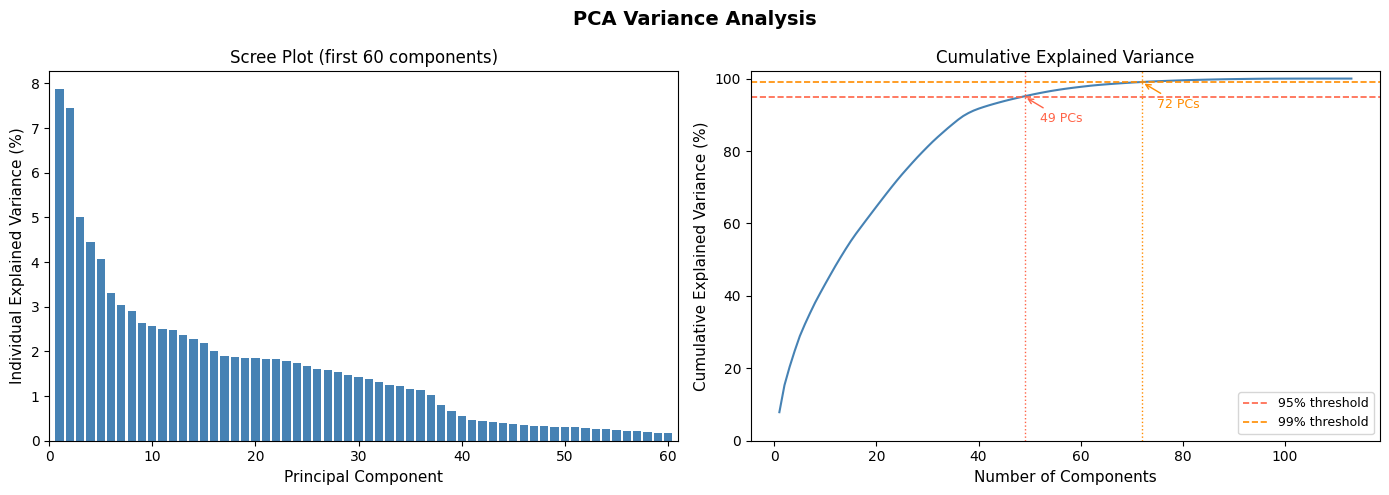


Variance captured by first 10 PCs: 43.3%
Variance captured by first 20 PCs: 64.6%


In [16]:
# --- 13.2 Scree plot + Cumulative Variance ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PCA Variance Analysis", fontsize=14, fontweight='bold')

# Scree plot (first 60 components)
n_show = min(60, n_total)
axes[0].bar(range(1, n_show + 1),
            pca_full.explained_variance_ratio_[:n_show] * 100,
            color='steelblue', edgecolor='none')
axes[0].set_xlabel("Principal Component", fontsize=11)
axes[0].set_ylabel("Individual Explained Variance (%)", fontsize=11)
axes[0].set_title(f"Scree Plot (first {n_show} components)", fontsize=12)
axes[0].set_xlim(0, n_show + 1)

# Cumulative variance curve
axes[1].plot(range(1, n_total + 1), cumvar * 100,
             color='steelblue', linewidth=1.5)
axes[1].axhline(95, color='tomato',     linestyle='--', linewidth=1.2, label='95% threshold')
axes[1].axhline(99, color='darkorange', linestyle='--', linewidth=1.2, label='99% threshold')
axes[1].axvline(n_components_95, color='tomato',     linestyle=':',  linewidth=1)
axes[1].axvline(n_components_99, color='darkorange', linestyle=':',  linewidth=1)
axes[1].annotate(f'{n_components_95} PCs', xy=(n_components_95, 95),
                 xytext=(n_components_95 + 3, 88), color='tomato', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='tomato', lw=1))
axes[1].annotate(f'{n_components_99} PCs', xy=(n_components_99, 99),
                 xytext=(n_components_99 + 3, 92), color='darkorange', fontsize=9,
                 arrowprops=dict(arrowstyle='->', color='darkorange', lw=1))
axes[1].set_xlabel("Number of Components", fontsize=11)
axes[1].set_ylabel("Cumulative Explained Variance (%)", fontsize=11)
axes[1].set_title("Cumulative Explained Variance", fontsize=12)
axes[1].legend(fontsize=9)
axes[1].set_ylim(0, 102)

plt.tight_layout()
plt.show()

print(f"\nVariance captured by first 10 PCs: {cumvar[9]*100:.1f}%")
print(f"Variance captured by first 20 PCs: {cumvar[19]*100:.1f}%")

In [17]:
# --- 13.3 Fit final PCA with selected n_components ---
# n_components is determined by the configurable variance threshold at the top of the notebook.
n_components_selected = int(np.searchsorted(cumvar, PCA_VARIANCE_THRESHOLD)) + 1

pca = PCA(n_components=n_components_selected, random_state=SEED)
X_train_pca = pca.fit_transform(X_train_proc)   # fit ONLY on training data
X_val_pca   = pca.transform(X_val_proc)          # apply same projection
X_test_pca  = pca.transform(X_test_proc)         # apply same projection

pca_feature_names = [f"PC{i+1}" for i in range(n_components_selected)]

print(f"Selected {n_components_selected} components "
      f"(≥{PCA_VARIANCE_THRESHOLD*100:.0f}% variance, "
      f"actual: {pca.explained_variance_ratio_.sum()*100:.2f}%)")
print(f"Dimensionality: {n_total} → {n_components_selected} "
      f"({100*(1 - n_components_selected/n_total):.1f}% reduction)")
print(f"\nX_train_pca shape: {X_train_pca.shape}")
print(f"X_val_pca shape:   {X_val_pca.shape}")
print(f"X_test_pca shape:  {X_test_pca.shape}")

Selected 49 components (≥95% variance, actual: 95.11%)
Dimensionality: 113 → 49 (56.6% reduction)

X_train_pca shape: (215253, 49)
X_val_pca shape:   (46126, 49)
X_test_pca shape:  (46126, 49)


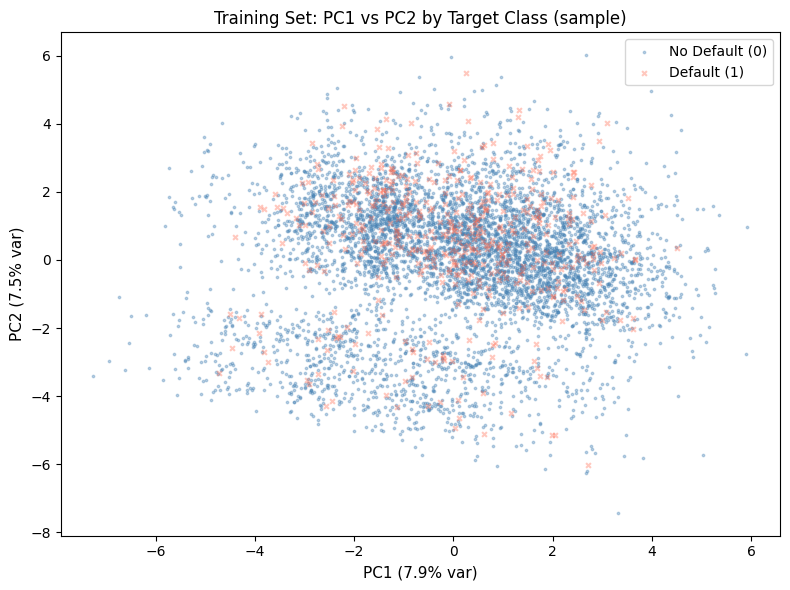

In [18]:
# --- 13.4 2D scatter: PC1 vs PC2 coloured by target ---
# Subsample for speed; class separation in 2D is usually modest for tabular credit data.
rng = np.random.default_rng(SEED)
sample_n = min(6000, len(X_train_pca))
idx = rng.choice(len(X_train_pca), size=sample_n, replace=False)

fig, ax = plt.subplots(figsize=(8, 6))
for label, color, marker, zorder in [(0, 'steelblue', '.', 1), (1, 'tomato', 'x', 2)]:
    mask = y_train.values[idx] == label
    ax.scatter(
        X_train_pca[idx][mask, 0],
        X_train_pca[idx][mask, 1],
        c=color, marker=marker, alpha=0.35, s=12, zorder=zorder,
        label=f"{'No Default (0)' if label == 0 else 'Default (1)'}"
    )
ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% var)", fontsize=11)
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% var)", fontsize=11)
ax.set_title("Training Set: PC1 vs PC2 by Target Class (sample)", fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

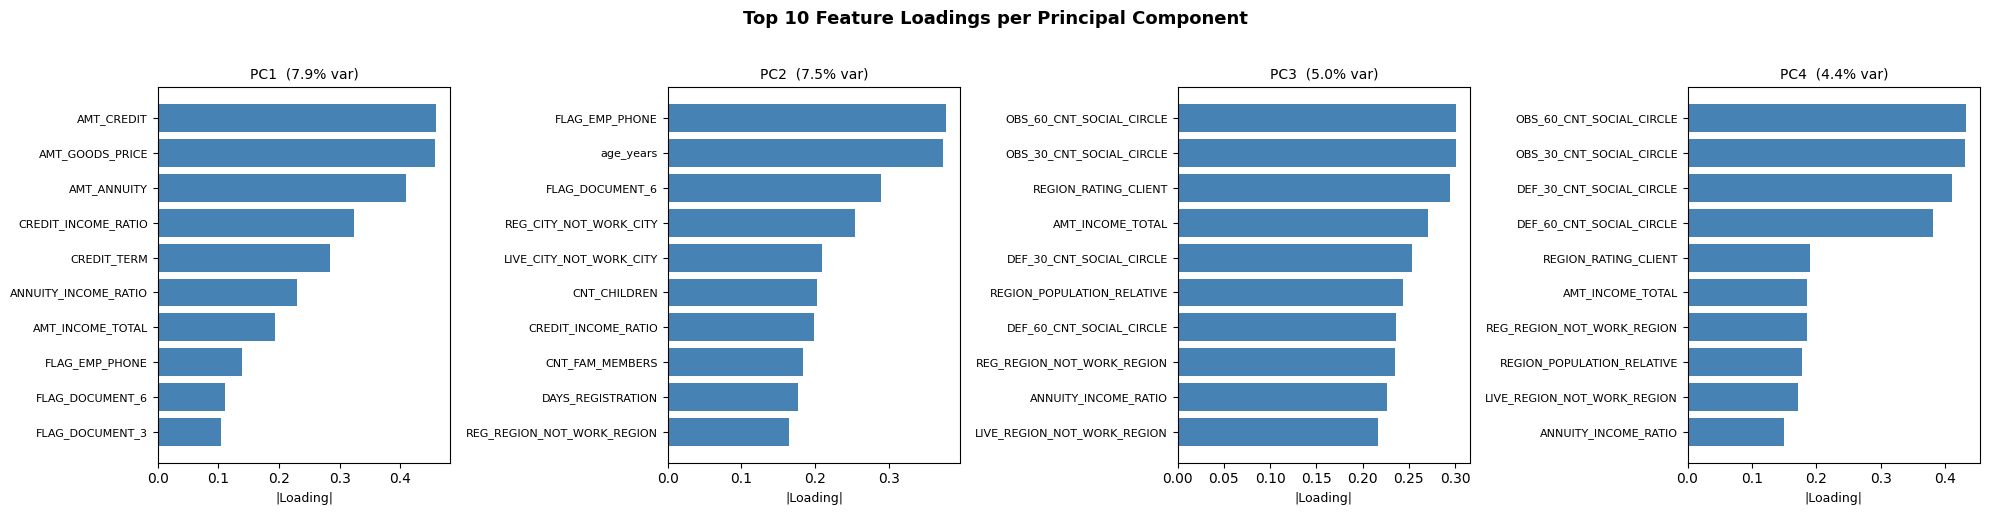


Top 10 contributing features to PC1:
  AMT_CREDIT                                   : 0.4592
  AMT_GOODS_PRICE                              : 0.4570
  AMT_ANNUITY                                  : 0.4089
  CREDIT_INCOME_RATIO                          : 0.3242
  CREDIT_TERM                                  : 0.2843
  ANNUITY_INCOME_RATIO                         : 0.2297
  AMT_INCOME_TOTAL                             : 0.1926
  FLAG_EMP_PHONE                               : 0.1389
  FLAG_DOCUMENT_6                              : 0.1109
  FLAG_DOCUMENT_3                              : 0.1048


In [19]:
# --- 13.5 Loading analysis: top contributing original features per PC ---
# Absolute loadings (components_) tell us which original features drive each PC.
# This is critical for interpretability — especially for Logistic Regression and Elastic Net
# where we later inspect coefficients in PC space.

N_TOP = 10
N_PCS_TO_SHOW = 4  # show loadings for the first 4 PCs

fig, axes = plt.subplots(1, N_PCS_TO_SHOW, figsize=(5 * N_PCS_TO_SHOW, 5), sharey=False)

for pc_idx in range(N_PCS_TO_SHOW):
    loadings = pd.Series(
        np.abs(pca.components_[pc_idx]),
        index=feature_names_raw
    ).nlargest(N_TOP)

    axes[pc_idx].barh(loadings.index[::-1], loadings.values[::-1], color='steelblue')
    axes[pc_idx].set_title(
        f"PC{pc_idx+1}  ({pca.explained_variance_ratio_[pc_idx]*100:.1f}% var)",
        fontsize=10
    )
    axes[pc_idx].set_xlabel("|Loading|", fontsize=9)
    axes[pc_idx].tick_params(axis='y', labelsize=8)

plt.suptitle(f"Top {N_TOP} Feature Loadings per Principal Component",
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Also print top features for PC1
print(f"\nTop {N_TOP} contributing features to PC1:")
top_pc1 = pd.Series(np.abs(pca.components_[0]), index=feature_names_raw).nlargest(N_TOP)
for feat, val in top_pc1.items():
    print(f"  {feat:45s}: {val:.4f}")

## 14. SMOTE — class imbalance handling (applied in PCA space)

SMOTE is applied **after PCA** so synthetic samples are interpolated in the reduced orthogonal
space rather than in the high-dimensional raw feature space. This is both computationally
cheaper and avoids synthesising unrealistic combinations of correlated OHE features.

**Rules:**
- Apply SMOTE **only** on X_train_pca. Never on val or test.
- Keep both versions so we can compare precision/recall trade-offs across models.

In [20]:
smote = SMOTE(random_state=SEED, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train_pca, y_train)

print(f"Before SMOTE: {X_train_pca.shape[0]:,} rows | default rate: {y_train.mean():.4f}")
print(f"After  SMOTE: {X_train_smote.shape[0]:,} rows | default rate: {y_train_smote.mean():.4f}")
print(f"SMOTE added {X_train_smote.shape[0] - X_train_pca.shape[0]:,} synthetic minority samples")

Before SMOTE: 215,253 rows | default rate: 0.0807
After  SMOTE: 395,752 rows | default rate: 0.5000
SMOTE added 180,499 synthetic minority samples


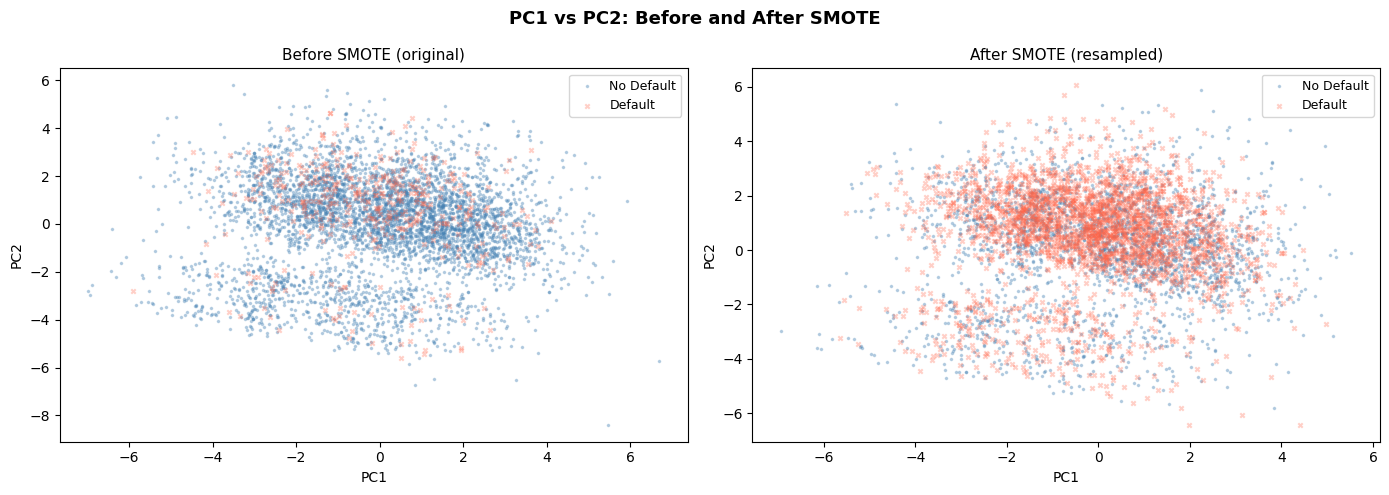

In [21]:
# 2D scatter comparing pre-SMOTE vs post-SMOTE in PC space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("PC1 vs PC2: Before and After SMOTE", fontsize=13, fontweight='bold')

datasets = [
    (X_train_pca,   y_train.values,  "Before SMOTE (original)"),
    (X_train_smote, y_train_smote,   "After SMOTE (resampled)"),
]

for ax, (X_plot, y_plot, title) in zip(axes, datasets):
    sample_n = min(5000, len(X_plot))
    idx = np.random.choice(len(X_plot), size=sample_n, replace=False)
    for label, color, marker in [(0, 'steelblue', '.'), (1, 'tomato', 'x')]:
        mask = y_plot[idx] == label
        ax.scatter(X_plot[idx][mask, 0], X_plot[idx][mask, 1],
                   c=color, marker=marker, alpha=0.3, s=10,
                   label=f"{'No Default' if label == 0 else 'Default'}")
    ax.set_xlabel("PC1", fontsize=10)
    ax.set_ylabel("PC2", fontsize=10)
    ax.set_title(title, fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 15. Save outputs

In [22]:
# Save PCA-reduced DataFrames with PC column names
train_out  = pd.DataFrame(X_train_pca,   columns=pca_feature_names)
val_out    = pd.DataFrame(X_val_pca,     columns=pca_feature_names)
test_out   = pd.DataFrame(X_test_pca,    columns=pca_feature_names)
smote_out  = pd.DataFrame(X_train_smote, columns=pca_feature_names)

train_out.to_csv(f"{OUT_DIR}/X_train.csv",       index=False)
val_out.to_csv(  f"{OUT_DIR}/X_val.csv",         index=False)
test_out.to_csv( f"{OUT_DIR}/X_test.csv",        index=False)
smote_out.to_csv(f"{OUT_DIR}/X_train_smote.csv", index=False)

y_train.reset_index(drop=True).to_csv(f"{OUT_DIR}/y_train.csv",       index=False)
y_val.reset_index(drop=True).to_csv(  f"{OUT_DIR}/y_val.csv",         index=False)
y_test.reset_index(drop=True).to_csv( f"{OUT_DIR}/y_test.csv",        index=False)
pd.Series(y_train_smote, name='TARGET').to_csv(f"{OUT_DIR}/y_train_smote.csv", index=False)

# Save fitted pipeline artifacts
joblib.dump(preprocessor, f"{OUT_DIR}/preprocessor.pkl")
joblib.dump(pca,          f"{OUT_DIR}/pca.pkl")

# Save PCA feature names (PC1, PC2, … PCk)
pd.Series(pca_feature_names).to_csv(f"{OUT_DIR}/feature_names.csv", index=False, header=False)

# Also save the original (pre-PCA) feature names for loading analysis downstream
pd.Series(feature_names_raw).to_csv(f"{OUT_DIR}/feature_names_raw.csv", index=False, header=False)

print("All outputs saved to:", OUT_DIR)
print(f"\nFiles written:")
for f in ['X_train.csv','X_val.csv','X_test.csv','X_train_smote.csv',
          'y_train.csv','y_val.csv','y_test.csv','y_train_smote.csv',
          'preprocessor.pkl','pca.pkl','feature_names.csv','feature_names_raw.csv']:
    print(f"  {OUT_DIR}/{f}")

All outputs saved to: /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca

Files written:
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/X_train.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/X_val.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/X_test.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/X_train_smote.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/y_train.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/y_val.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/y_test.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/y_train_smote.csv
  /content/drive/MyDrive/MLDL-RADU/loan-default-project/01_data/03_processed_pca/preprocessor.pkl
  /content/drive/MyDrive/MLDL-RADU/

## 16. Preprocessing + PCA Summary

In [23]:
summary = {
    'Raw features':                           122,
    'Rows dropped (XNA/Unknown)':             6,
    'Columns dropped':                        len(existing_drops),
    'Engineered features added':              7,
    'EXT_SOURCE missingness flags':           len(ext_missing_flags),
    'Features after OHE (pre-PCA)':           n_total,
    'PCA variance threshold':                 f"{PCA_VARIANCE_THRESHOLD*100:.0f}%",
    'PCA components selected':                n_components_selected,
    'Actual variance retained':               f"{pca.explained_variance_ratio_.sum()*100:.2f}%",
    'Dimensionality reduction':               f"{n_total} → {n_components_selected} ({100*(1-n_components_selected/n_total):.1f}% reduction)",
    'Train samples (no SMOTE)':               X_train_pca.shape[0],
    'Train samples (SMOTE)':                  X_train_smote.shape[0],
    'Val samples':                            X_val_pca.shape[0],
    'Test samples':                           X_test_pca.shape[0],
    'Train default rate':                     round(float(y_train.mean()), 4),
    'SMOTE default rate':                     round(float(y_train_smote.mean()), 4),
}

pd.Series(summary).rename('value').to_frame()

,value
Raw features,122
Rows dropped (XNA/Unknown),6
Columns dropped,66
Engineered features added,7
EXT_SOURCE missingness flags,3
Features after OHE (pre-PCA),113
PCA variance threshold,95%
PCA components selected,49
Actual variance retained,95.11%
Dimensionality reduction,113 → 49 (56.6% reduction)


---
## Preprocessing + PCA checklist

| Step | Status | Note |
|------|--------|------|
| Drop high-missing cols (G1 building block) | ✅ | Section 4 |
| DAYS_EMPLOYED sentinel → NaN + flag | ✅ | Section 3.1 |
| DAYS_BIRTH → age_years | ✅ | Section 3.2 |
| Flip sign on DAYS_* columns | ✅ | Section 3.3 |
| Ratio features (credit/income, annuity/income, term, goods) | ✅ | Section 3.4 |
| Drop XNA/Unknown rows | ✅ | Section 2 |
| Drop zero-variance flags | ✅ | Section 4 |
| Hard-cap extreme counts | ✅ | Section 5 |
| Train/val/test split 70/15/15 stratified | ✅ | Section 6 |
| Semantic NaN imputation | ✅ | Section 8 |
| Rare category grouping (<1%) | ✅ | Section 9 |
| Winsorize monetary at 99th pct | ✅ | Section 10 |
| log1p on monetary columns | ✅ | Section 10 |
| EXT_SOURCE missingness flags | ✅ | Section 7.4 |
| Ordinal encode NAME_EDUCATION_TYPE | ✅ | Section 10 |
| One-hot encode categoricals | ✅ | Section 10 |
| StandardScaler on all numerics | ✅ | Section 10 |
| Variance analysis (scree + cumulative plot) | ✅ | Section 13.2 |
| PCA fitted on training set only (no leakage) | ✅ | Section 13.3 |
| 2D PC scatter plot | ✅ | Section 13.4 |
| Loading analysis (top features per PC) | ✅ | Section 13.5 |
| SMOTE applied in PCA space (train only) | ✅ | Section 14 |
| Save all splits + preprocessor + PCA | ✅ | Section 15 |